In [1]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import shap
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess


In [2]:
df_ena_abs = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_abs_r_block.csv')
df_sgp_abs = pd.read_csv('/data/ggong/ARM_monthly/SGP/csv_file/df_abs_r_block.csv')

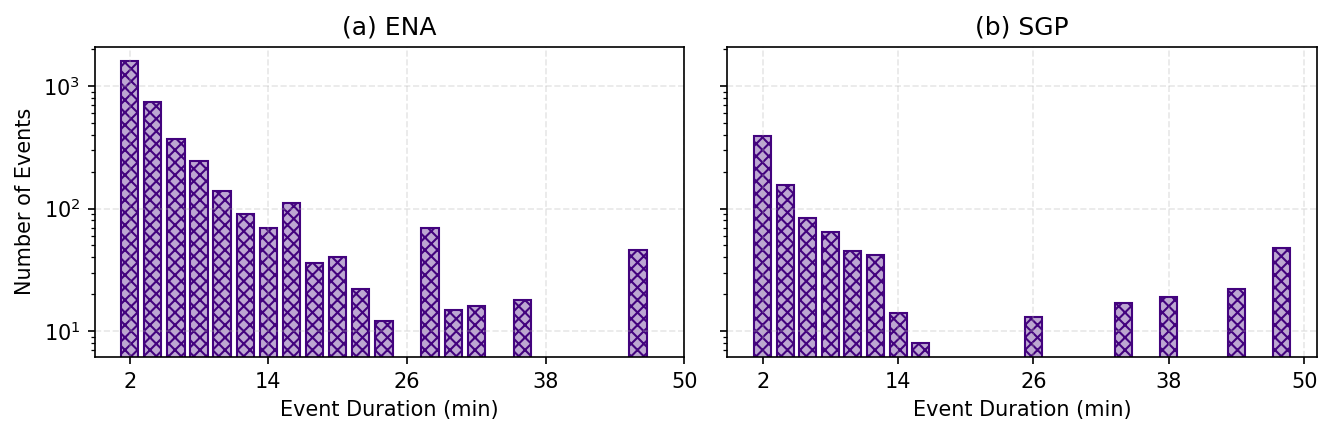

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), dpi=150, sharey=True)
col = "#43037e"
def lighten(c,a=0.65):
    rgb=np.array(mcolors.to_rgb(c)); return tuple(rgb+(1-rgb)*a)
for ax, df, title in zip(axes, [df_ena_abs, df_sgp_abs], ["(a) ENA", "(b) SGP"]):
    c = (df["n_samples"] * 2).value_counts().sort_index()
    ax.grid(ls='--',alpha=0.3)
    ax.bar(c.index, c.values, 1.5, color=lighten(col), edgecolor=col, lw=1, hatch="xxxx")
    ax.set_yscale("log")
    ax.set_xticks([2, 14, 26, 38, 50])
    ax.set_xlabel("Event Duration (min)")
    ax.set_title(title)
    
axes[0].set_ylabel("Number of Events")
plt.tight_layout()
plt.savefig("figsave/event_number.pdf",dpi=300,bbox_inches="tight")
plt.show()

### ARM Seasonal occurrence fractions, Fig. S3


ENA counts:
label   bottom  middle  top
season                     
DJF        531     327   64
MAM        385     225   40
JJA        786     280   81
SON        504     384   51

ENA percentage:
label   bottom  middle  top
season                     
DJF       57.6    35.5  6.9
MAM       59.2    34.6  6.2
JJA       68.5    24.4  7.1
SON       53.7    40.9  5.4

SGP counts:
label   bottom  middle  top
season                     
DJF         37      91    0
MAM        325     141    4
JJA         73      24    1
SON        172      49    3

SGP percentage:
label   bottom  middle  top
season                     
DJF       28.9    71.1  0.0
MAM       69.1    30.0  0.9
JJA       74.5    24.5  1.0
SON       76.8    21.9  1.3


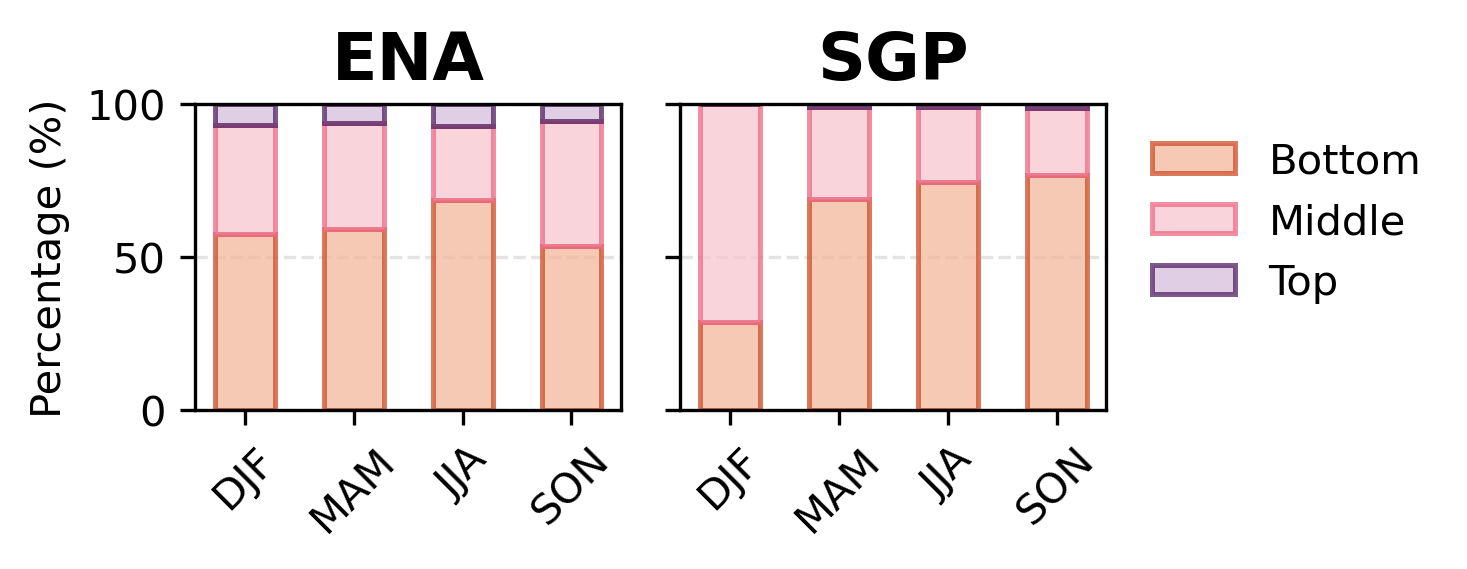

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

dfs = {"ENA": df_ena_abs, "SGP": df_sgp_abs}
smap = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}
seasons, labels = ["DJF","MAM","JJA","SON"], ["bottom","middle","top"]
colors, edges = ["#f3b79c","#f7c6d0","#d6c0db"], ["#cf4e28","#ee6a85","#532162"]

fig, axes = plt.subplots(1, 2, figsize=(5, 2), dpi=300, sharey=True)

for ax, (site, d) in zip(axes, dfs.items()):
    d = d.copy()
    d["season"] = d["month"].map(smap)
    d["label"] = d["label"].str.lower()

    cnt = pd.crosstab(d["season"], d["label"]).reindex(index=seasons, columns=labels, fill_value=0)
    pct = cnt.div(cnt.sum(1), axis=0).mul(100)

    print(f"\n{site} counts:\n{cnt}")
    print(f"\n{site} percentage:\n{pct.round(1)}")

    bot = np.zeros(len(pct))
    for lab, fc, ec in zip(labels, colors, edges):
        ax.bar(pct.index, pct[lab], bottom=bot, color=fc, edgecolor=ec,
               width=0.55, lw=1.2, alpha=0.75, label=lab.capitalize())
        bot += pct[lab].values

    ax.set_title(site, fontsize=16, weight="bold")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", ls="--", alpha=0.35)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Percentage (%)")
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig("figsave/seasonal_abs_percentage.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Fig.2a

Event counts:
 label  bottom  middle  top
ENA      1245     809  204
SGP       339     188    8

Percentages:
 label  bottom  middle  top
ENA      55.1    35.8  9.0
SGP      63.4    35.1  1.5


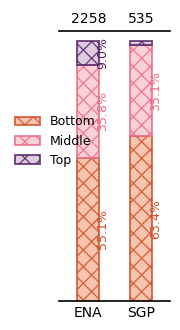

In [6]:
dfs = {"ENA": df_ena_abs, "SGP": df_sgp_abs}
cats = ["bottom", "middle", "top"]
labels = {"bottom":"Bottom", "middle":"Middle", "top":"Top"}
colors = {"bottom":"#f3b79c", "middle":"#f7c6d0", "top":"#d6c0db"}
edges  = {"bottom":"#cf4e28", "middle":"#ee6a85", "top":"#532162"}

cnt = pd.DataFrame({
    s: (d.assign(label=d["label"].astype(str).str.lower())
         .drop_duplicates("event_id")["label"]
         .value_counts().reindex(cats, fill_value=0))
    for s,d in dfs.items()
}).T

pct = cnt.div(cnt.sum(1), axis=0) * 100

print("Event counts:\n", cnt)
print("\nPercentages:\n", pct.round(1))

fig, ax = plt.subplots(figsize=(2.2,3.4), dpi=100)
x, bot = np.arange(len(dfs)), np.zeros(len(dfs))

for c in cats:
    vals=pct[c].values
    ax.bar(x,vals,bottom=bot,width=0.42,color=colors[c],edgecolor=edges[c],lw=1.4,alpha=0.8,hatch="xx",label=labels[c],zorder=2)
    for xi,v,b in zip(x,vals,bot):
        if v>3: ax.text(xi+0.27,b+v/2,f"{v:.1f}%",ha="center",va="center",rotation=90,fontsize=9,color=edges[c],clip_on=False)
    bot+=vals

for xi,site in zip(x,dfs):
    ax.text(xi,106,f"{cnt.loc[site].sum():.0f}",ha="center",va="bottom",fontsize=10,clip_on=False)

ax.set(xticks=x,xticklabels=list(dfs),xlim=(-0.55,len(dfs)-0.45),ylim=(0,112),yticks=[])
ax.tick_params(axis="x",length=0)
for s in ["left","right","top"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.axhline(104,color="k",lw=1.2,clip_on=False)
ax.legend(frameon=False,fontsize=9,loc="center left",bbox_to_anchor=(-0.5,0.55))
plt.tight_layout()
plt.savefig("figsave/event_prec.pdf",dpi=300,bbox_inches="tight")
plt.show()

## Cloud droplet radius sensitivity, Fig. 3

In [7]:
cats, cat_labels = ["top","middle","bottom"], ["Top","Middle","Bottom"]
lwp_groups = [("20–60",lambda x:(x>=20)&(x<60)), ("60–100",lambda x:(x>=60)&(x<100)), (">100",lambda x:x>=100)]
seasons = ["DJF","MAM","JJA","SON"]
m2s = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}
lwp_cols, sea_cols = ["#4988C4","#547792","#002855"], ["#7f7f7f","#a5be00","#38a3a5","#eb5e28"]
dod_max, min_count, B = 5e-1, 20, 2000
rng = np.random.default_rng(42)

def lighten(c,a=.65):
    x=np.array(mcolors.to_rgb(c)); return tuple(x+(1-x)*a)

def prep(df):
    d=df[["event_id","label","month","main_dod","lwp","Re"]].copy()
    d["label"]=d.label.astype(str).str.lower()
    d["month"]=pd.to_numeric(d.month,errors="coerce"); d["season"]=d.month.map(m2s)
    for v in ["main_dod","lwp","Re"]: d[v]=pd.to_numeric(d[v],errors="coerce")
    d=d[np.isfinite(d.main_dod)&np.isfinite(d.Re)&(d.main_dod>0)&(d.main_dod<=dod_max)&(d.Re>0)].copy()
    d["lnDOD"],d["lnRe"]=np.log(d.main_dod),np.log(d.Re)
    for v in ["lnDOD","lnRe"]: d["z_"+v]=(d[v]-d[v].mean())/d[v].std(ddof=1)
    return d

def block_fit(d):
    d=d[["event_id","z_lnDOD","z_lnRe"]].dropna()
    n,ne=len(d),d.event_id.nunique()
    if n<min_count or ne<2: return [np.nan]*6+[n,ne]

    fit=linregress(d.z_lnDOD,d.z_lnRe)
    groups=dict(tuple(d.groupby("event_id"))); ids=np.array(list(groups))
    bs=[]

    for _ in range(B):
        db=pd.concat([groups[i] for i in rng.choice(ids,len(ids),replace=True)],ignore_index=True)
        if db.z_lnDOD.nunique()>1:
            bs.append(-linregress(db.z_lnDOD,db.z_lnRe).slope)

    beta=-fit.slope
    bse=np.std(bs,ddof=1)
    lo,hi=np.percentile(bs,[2.5,97.5])
    pboot=2*min(np.mean(np.array(bs)<=0),np.mean(np.array(bs)>=0))
    return beta,bse,lo,hi,fit.rvalue,pboot,n,ne

def get_sens(df,site):
    d=prep(df)
    allv,allse=np.full(3,np.nan),np.full(3,np.nan)
    lwpv,lwpse=np.full((3,3),np.nan),np.full((3,3),np.nan)
    seav,sease=np.full((4,3),np.nan),np.full((4,3),np.nan)
    rows=[]

    def run(dd,g,c):
        beta,se,lo,hi,r,p,n,ne=block_fit(dd)
        rows.append([site,c.capitalize(),g,ne,beta,se,lo,hi,r,p])
        return beta,se

    for j,c in enumerate(cats):
        dc=d[d.label.eq(c)]
        allv[j],allse[j]=run(dc,"All",c)

        for i,(g,f) in enumerate(lwp_groups):
            lwpv[i,j],lwpse[i,j]=run(dc[np.isfinite(dc.lwp)&f(dc.lwp)],f"LWP {g}",c)

        for i,s in enumerate(seasons):
            seav[i,j],sease[i,j]=run(dc[dc.season.eq(s)],s,c)

    cols=["Site","Configuration","Group","N_events","Beta",
          "Bootstrap_SE","CI95_low","CI95_high","Pearson_r","Bootstrap_p"]

    return (allv,allse,lwpv,lwpse,seav,sease),pd.DataFrame(rows,columns=cols)

ena,ena_stats=get_sens(df_ena_abs,"ENA")
sgp,sgp_stats=get_sens(df_sgp_abs,"SGP")
stats=pd.concat([ena_stats,sgp_stats],ignore_index=True)

print(stats.round(3).to_string(index=False))


Site Configuration      Group  N_events   Beta  Bootstrap_SE  CI95_low  CI95_high  Pearson_r  Bootstrap_p
 ENA           Top        All       204  0.134         0.060     0.024      0.257     -0.131        0.023
 ENA           Top  LWP 20–60       131  0.115         0.089    -0.060      0.294     -0.096        0.178
 ENA           Top LWP 60–100        55  0.111         0.100    -0.026      0.380     -0.152        0.120
 ENA           Top   LWP >100        24  0.268         0.239    -0.337      0.615     -0.218        0.270
 ENA           Top        DJF        53  0.189         0.157    -0.087      0.520     -0.148        0.183
 ENA           Top        MAM        39 -0.004         0.131    -0.308      0.225      0.006        0.968
 ENA           Top        JJA        66  0.207         0.113     0.028      0.471     -0.190        0.014
 ENA           Top        SON        46  0.100         0.137    -0.184      0.346     -0.087        0.445
 ENA        Middle        All       809  0.076

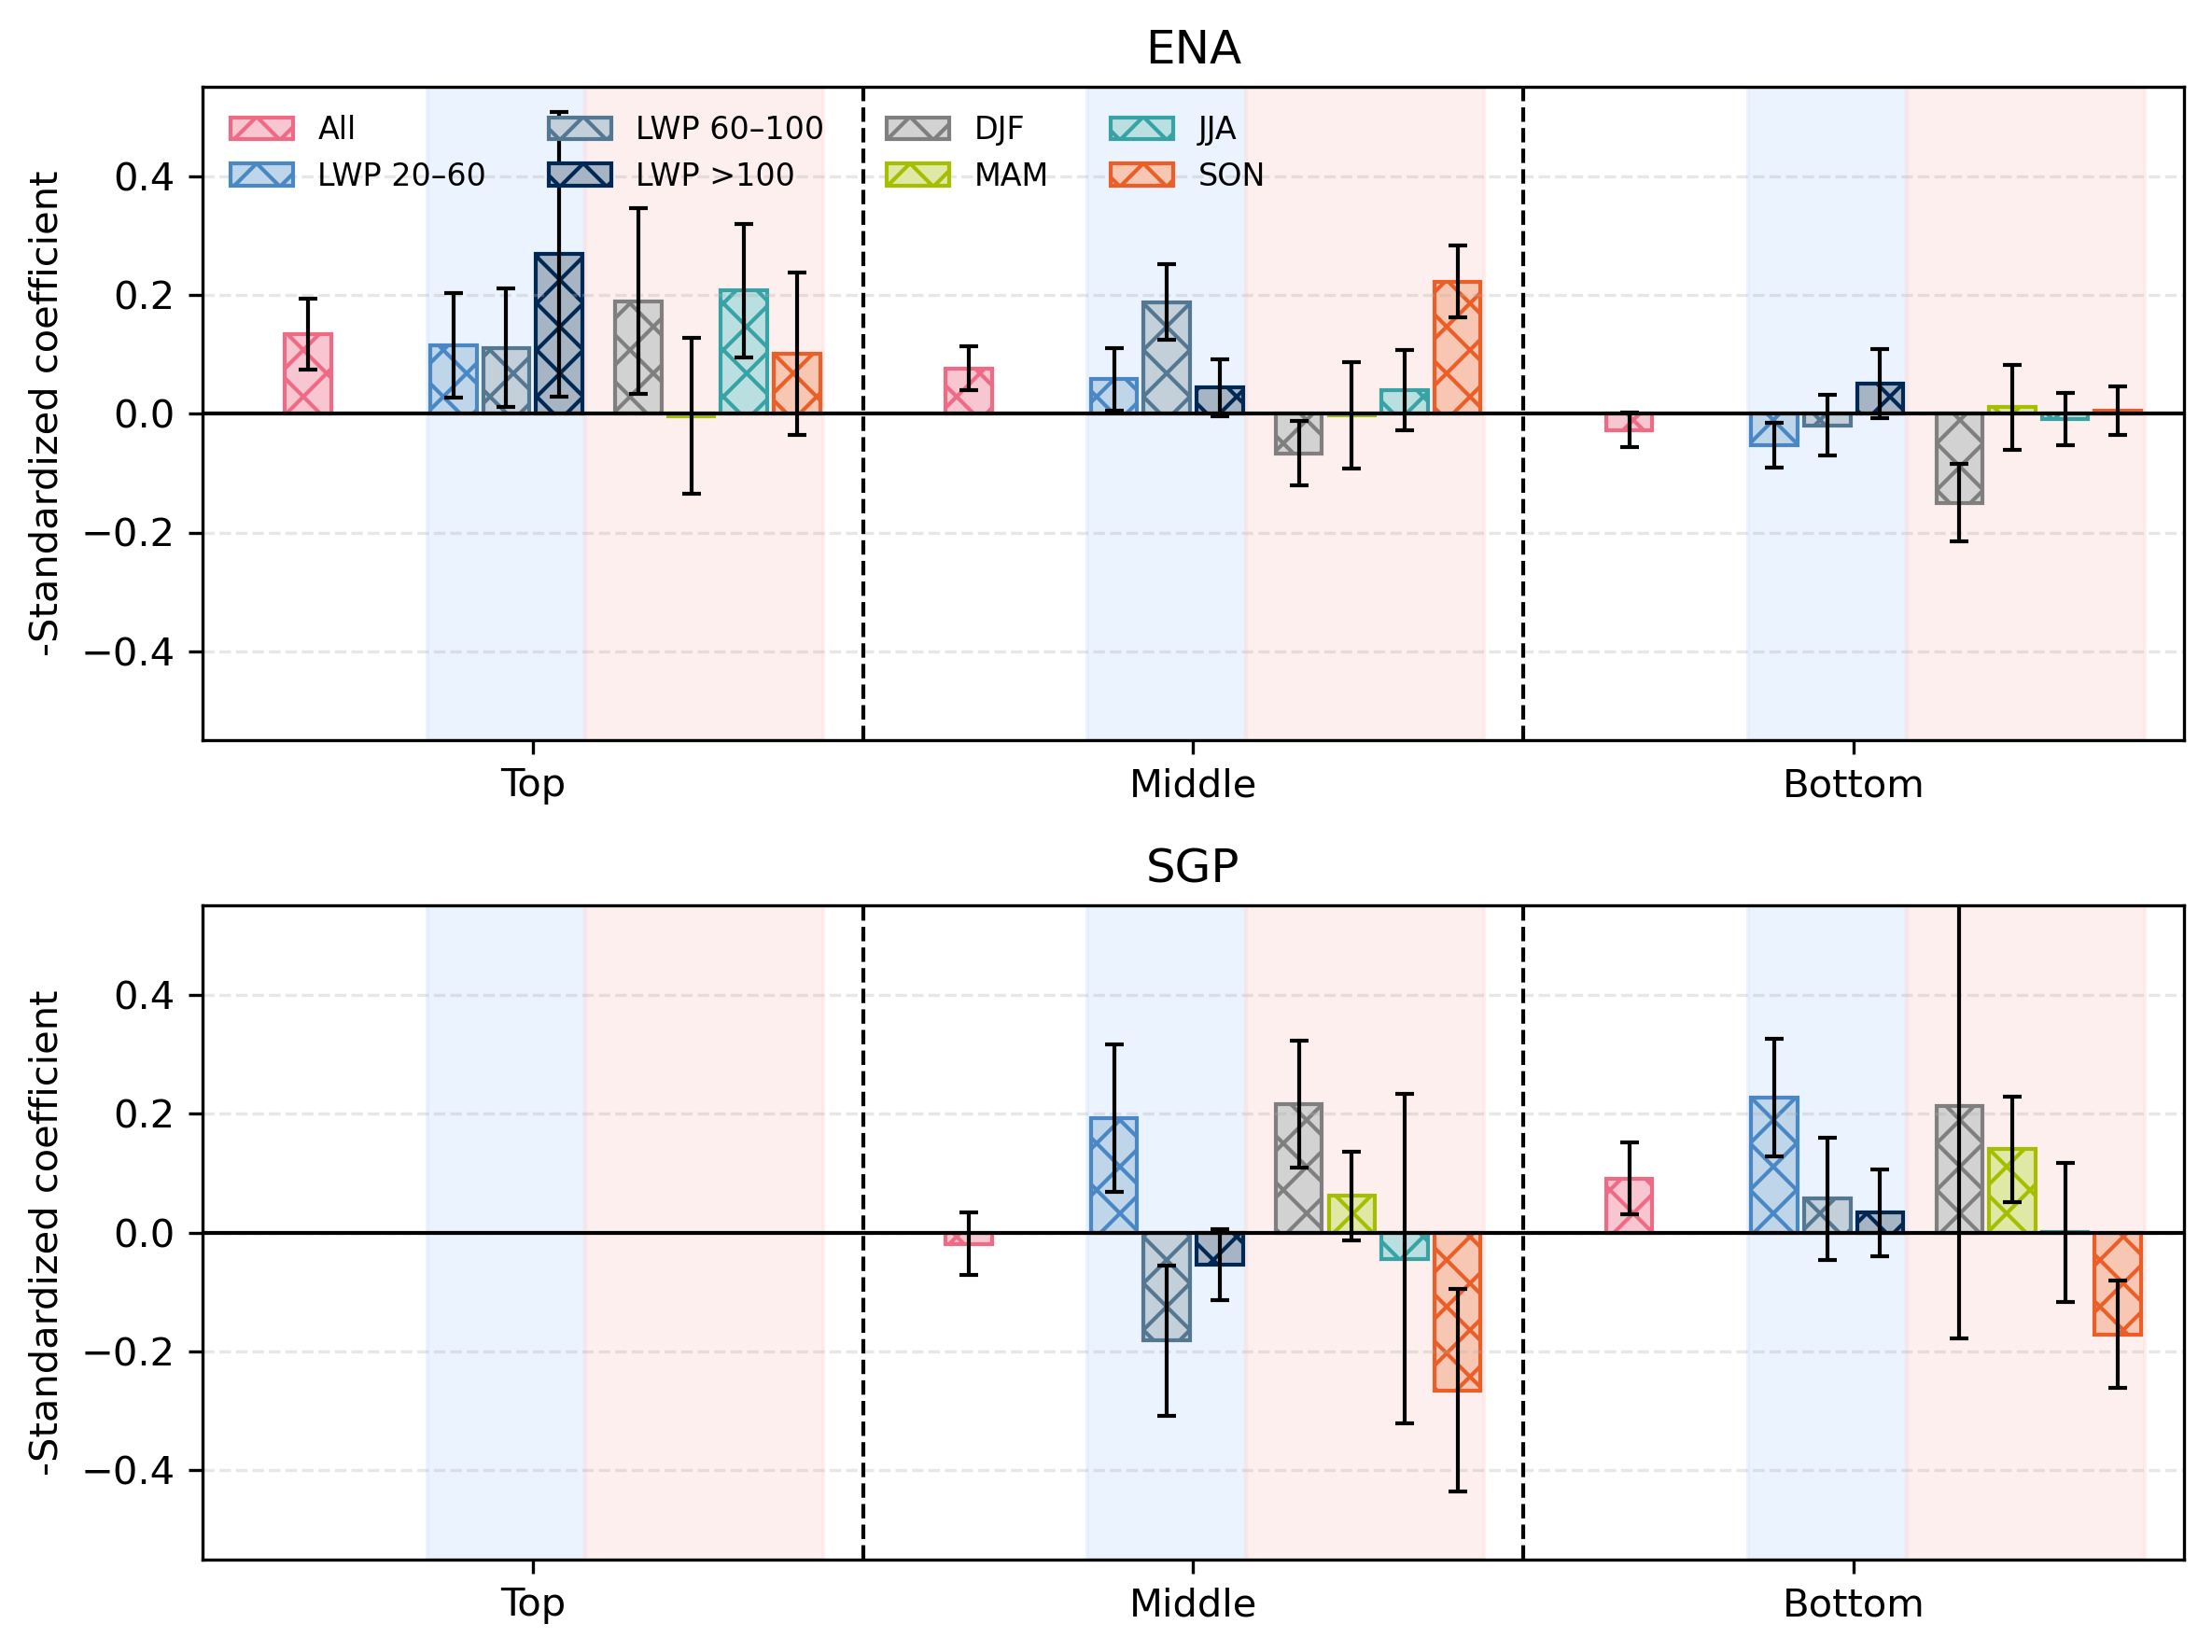

In [8]:

# ===================== Figure =====================
fig,axes=plt.subplots(2,1,figsize=(8,6),dpi=300,sharey=True)
x,w=np.arange(3),.07
x_all=x-.34; x_lwp=[x-.12,x-.04,x+.04]; x_sea=[x+.16,x+.24,x+.32,x+.40]
errkw=dict(ecolor="k",elinewidth=1,capsize=2.5,capthick=1)

for ax,title,dat in zip(axes,["ENA","SGP"],[ena,sgp]):
    allv,allse,lwpv,lwpse,seav,sease=dat

    for xi in x:
        ax.axvspan(xi-.16,xi+.08,color="#dbeafe",alpha=.55,zorder=0)
        ax.axvspan(xi+.08,xi+.44,color="#fee2e2",alpha=.55,zorder=0)

    b0=ax.bar(x_all,allv,w,yerr=allse,color="#f7c6d0",edgecolor="#ee6a85",
              lw=1,hatch="xx",error_kw=errkw,label="All")

    bl=[ax.bar(x_lwp[i],lwpv[i],w,yerr=lwpse[i],color=lighten(lwp_cols[i]),
               edgecolor=lwp_cols[i],lw=1,hatch="xx",error_kw=errkw)
        for i in range(3)]

    bs=[ax.bar(x_sea[i],seav[i],w,yerr=sease[i],color=lighten(sea_cols[i]),
               edgecolor=sea_cols[i],lw=1,hatch="xx",error_kw=errkw)
        for i in range(4)]

    ax.axhline(0,color="k",lw=1)
    for v in [.5,1.5]: ax.axvline(v,color="k",lw=1,ls="--")
    ax.set(xlim=(-.5,2.5),ylim=(-.55,.55),xticks=x,xticklabels=cat_labels,
           ylabel="-Standardized coefficient",title=title)
    ax.grid(axis="y",alpha=.3,ls="--")

axes[0].legend([b0,*bl,*bs],
    ["All","LWP 20–60","LWP 60–100","LWP >100","DJF","MAM","JJA","SON"],
    frameon=False,ncol=4,loc="upper left",fontsize=8)

plt.tight_layout()
plt.savefig("figsave/Figure3_block_bootstrap.pdf",dpi=300,bbox_inches="tight")
plt.show()

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import linregress

cats_ena, cats_sgp = ["top","middle","bottom"], ["middle","bottom"]
cat_labels = {"top":"Top","middle":"Middle","bottom":"Bottom"}
lwp_groups = [("100–140",lambda x:(x>=100)&(x<140)),
              ("140–180",lambda x:(x>=140)&(x<180)),
              ("180–220",lambda x:(x>=180)&(x<220)),
              (">220",lambda x:x>=220)]
cols = ["#4988C4","#547792","#24527A","#002855"]
dod_max, min_count, B = 5e-1, 20, 2000
rng = np.random.default_rng(42)

def lighten(c,a=.65):
    x=np.array(mcolors.to_rgb(c)); return tuple(x+(1-x)*a)

def prep(df):
    d=df[["event_id","label","main_dod","Re","lwp"]].copy()
    d["label"]=d.label.astype(str).str.lower()
    for v in ["main_dod","Re","lwp"]: d[v]=pd.to_numeric(d[v],errors="coerce")
    d=d[np.isfinite(d.main_dod)&np.isfinite(d.Re)&(d.main_dod>0)&
        (d.main_dod<=dod_max)&(d.Re>0)].copy()
    d["lnDOD"],d["lnRe"]=np.log(d.main_dod),np.log(d.Re)
    for v in ["lnDOD","lnRe"]: d["z_"+v]=(d[v]-d[v].mean())/d[v].std(ddof=1)
    return d

def block_fit(d):
    d=d[["event_id","z_lnDOD","z_lnRe"]].dropna()
    n,ne=len(d),d.event_id.nunique()
    if n<min_count or ne<2: return np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,n,ne

    fit=linregress(d.z_lnDOD,d.z_lnRe)
    g=d.groupby("event_id")
    a=g.agg(n=("z_lnDOD","size"), sx=("z_lnDOD","sum"), sy=("z_lnRe","sum"))
    a["sxx"]=g["z_lnDOD"].apply(lambda x:(x*x).sum())
    a["sxy"]=g.apply(lambda x:(x.z_lnDOD*x.z_lnRe).sum(),include_groups=False)

    C=rng.multinomial(ne,np.repeat(1/ne,ne),size=B)
    N=C@a.n.values; sx=C@a.sx.values; sy=C@a.sy.values
    sxx=C@a.sxx.values; sxy=C@a.sxy.values
    bs=-(sxy-sx*sy/N)/(sxx-sx*sx/N)
    bs=bs[np.isfinite(bs)]

    beta=-fit.slope
    se=np.std(bs,ddof=1)
    lo,hi=np.percentile(bs,[2.5,97.5])
    pboot=2*min((bs<=0).mean(),(bs>=0).mean())
    return beta,se,lo,hi,fit.rvalue,pboot,n,ne

def get_lwp_sens(df,cats,site):
    d=prep(df)
    val=np.full((4,len(cats)),np.nan); se=val.copy()
    rows=[]

    for j,c in enumerate(cats):
        dc=d[d.label.eq(c)]
        for i,(g,f) in enumerate(lwp_groups):
            dl=dc[np.isfinite(dc.lwp)&f(dc.lwp)]
            b,s,lo,hi,r,p,n,ne=block_fit(dl)
            val[i,j],se[i,j]=b,s
            rows.append([site,cat_labels[c],g,ne,b,s,lo,hi,r,p])

    cols=["Site","Configuration","LWP","N_events","Beta",
          "Bootstrap_SE","CI95_low","CI95_high","Pearson_r","Bootstrap_p"]
    return (val,se),pd.DataFrame(rows,columns=cols)

ena,ena_stats=get_lwp_sens(df_ena_abs,cats_ena,"ENA")
sgp,sgp_stats=get_lwp_sens(df_sgp_abs,cats_sgp,"SGP")
stats_df=pd.concat([ena_stats,sgp_stats],ignore_index=True)

print(stats_df.round(3).to_string(index=False))


Site Configuration     LWP  N_events   Beta  Bootstrap_SE  CI95_low  CI95_high  Pearson_r  Bootstrap_p
 ENA           Top 100–140        15    NaN           NaN       NaN        NaN        NaN          NaN
 ENA           Top 140–180         4    NaN           NaN       NaN        NaN        NaN          NaN
 ENA           Top 180–220         1    NaN           NaN       NaN        NaN        NaN          NaN
 ENA           Top    >220         4    NaN           NaN       NaN        NaN        NaN          NaN
 ENA        Middle 100–140       192  0.072         0.063    -0.058      0.188     -0.091        0.291
 ENA        Middle 140–180        96  0.055         0.084    -0.105      0.220     -0.057        0.521
 ENA        Middle 180–220        60  0.127         0.119    -0.116      0.346     -0.138        0.326
 ENA        Middle    >220        80 -0.123         0.130    -0.377      0.151      0.115        0.351
 ENA        Bottom 100–140       187  0.063         0.075    -0.072      

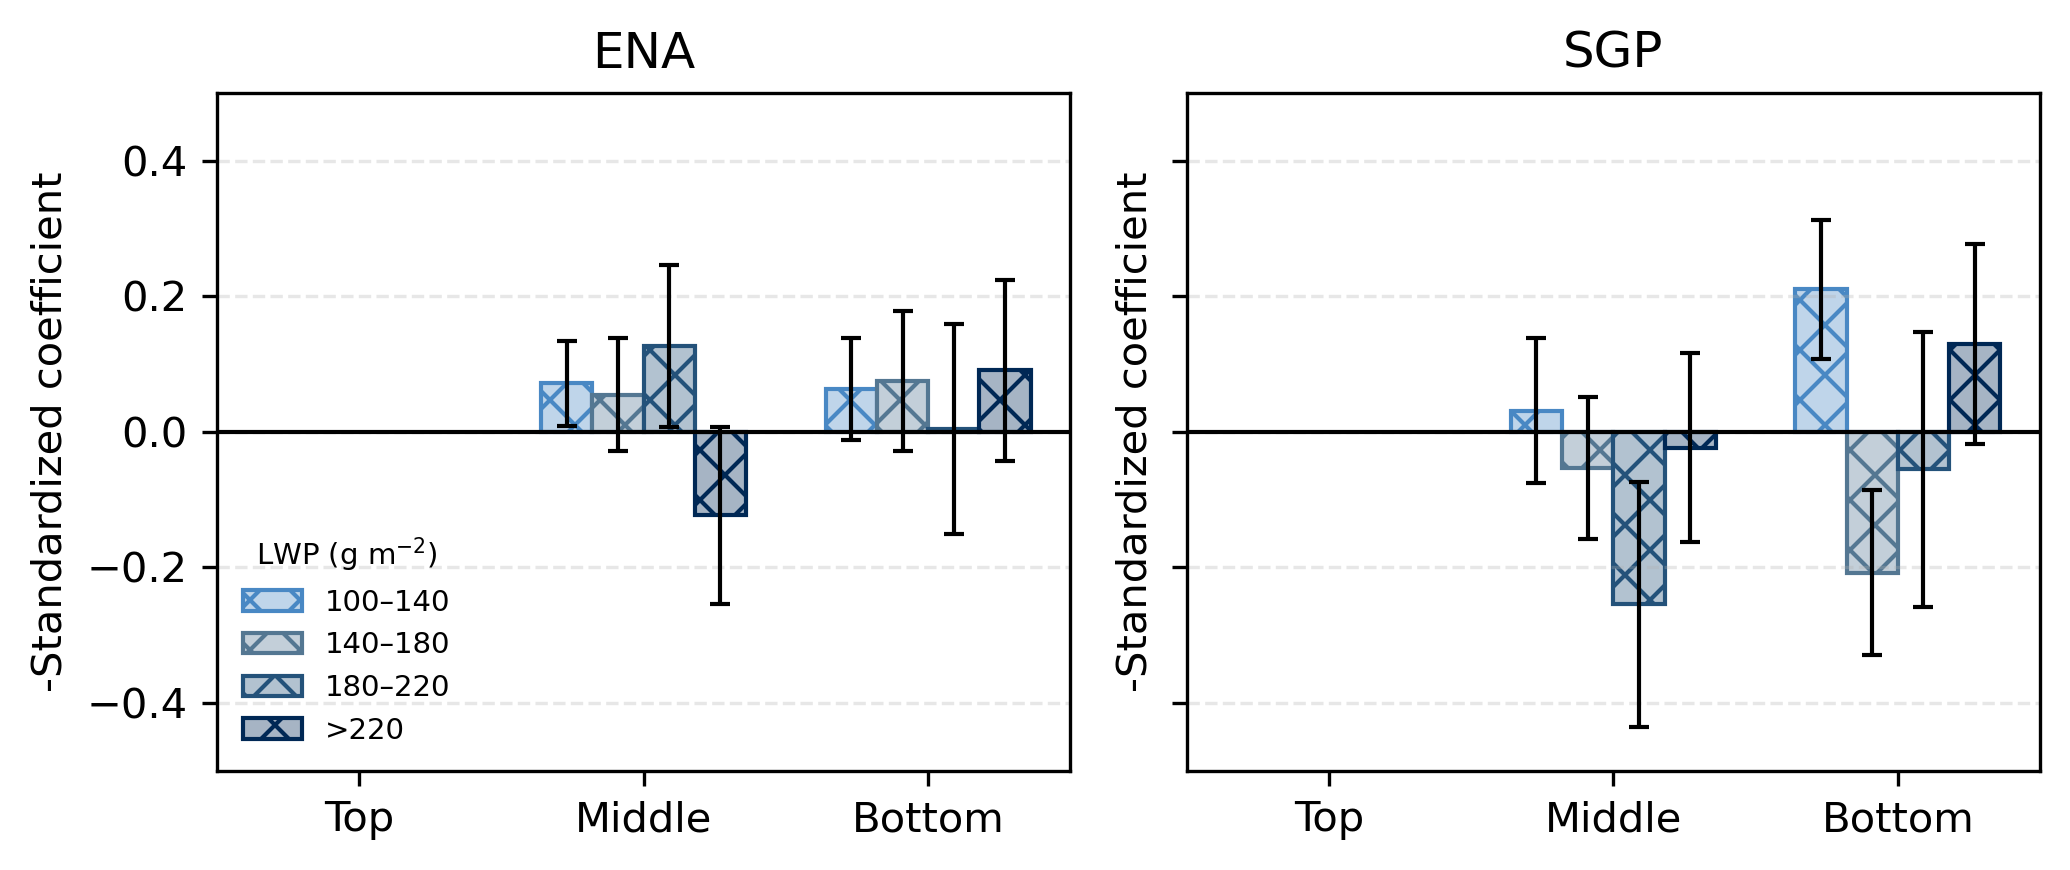

In [10]:

# Plot
fig,axes=plt.subplots(1,2,figsize=(7,3),dpi=300,sharey=True)
errkw=dict(ecolor="k",elinewidth=1,capsize=2.5,capthick=1)

for ax,title,cats,dat in zip(axes,["ENA","SGP"],[cats_ena,cats_sgp],[ena,sgp]):
    val,se=dat
    x=np.arange(3) if title=="ENA" else np.array([1,2])
    w=.18; offsets=np.array([-1.5,-.5,.5,1.5])*w

    for i,(g,_) in enumerate(lwp_groups):
        ax.bar(x+offsets[i],val[i],w,yerr=se[i],color=lighten(cols[i]),
               edgecolor=cols[i],lw=1,hatch="xx",error_kw=errkw,label=g)

    ax.axhline(0,color="k",lw=1)
    ax.set(xticks=[0,1,2],xticklabels=["Top","Middle","Bottom"],
           xlim=(-.5,2.5),ylim=(-.5,.5),
           ylabel="-Standardized coefficient",title=title)
    ax.grid(axis="y",alpha=.3,ls="--")

axes[0].legend(title="LWP (g m$^{-2}$)",frameon=False,fontsize=7,title_fontsize=7)
plt.tight_layout()
plt.savefig("figsave/FigureSlwp_100_block.pdf",dpi=300,bbox_inches="tight")
plt.show()

## Confounding influence of meteorology on dust-cloud interactions under different dust–cloud vertical configurations. Fig 4

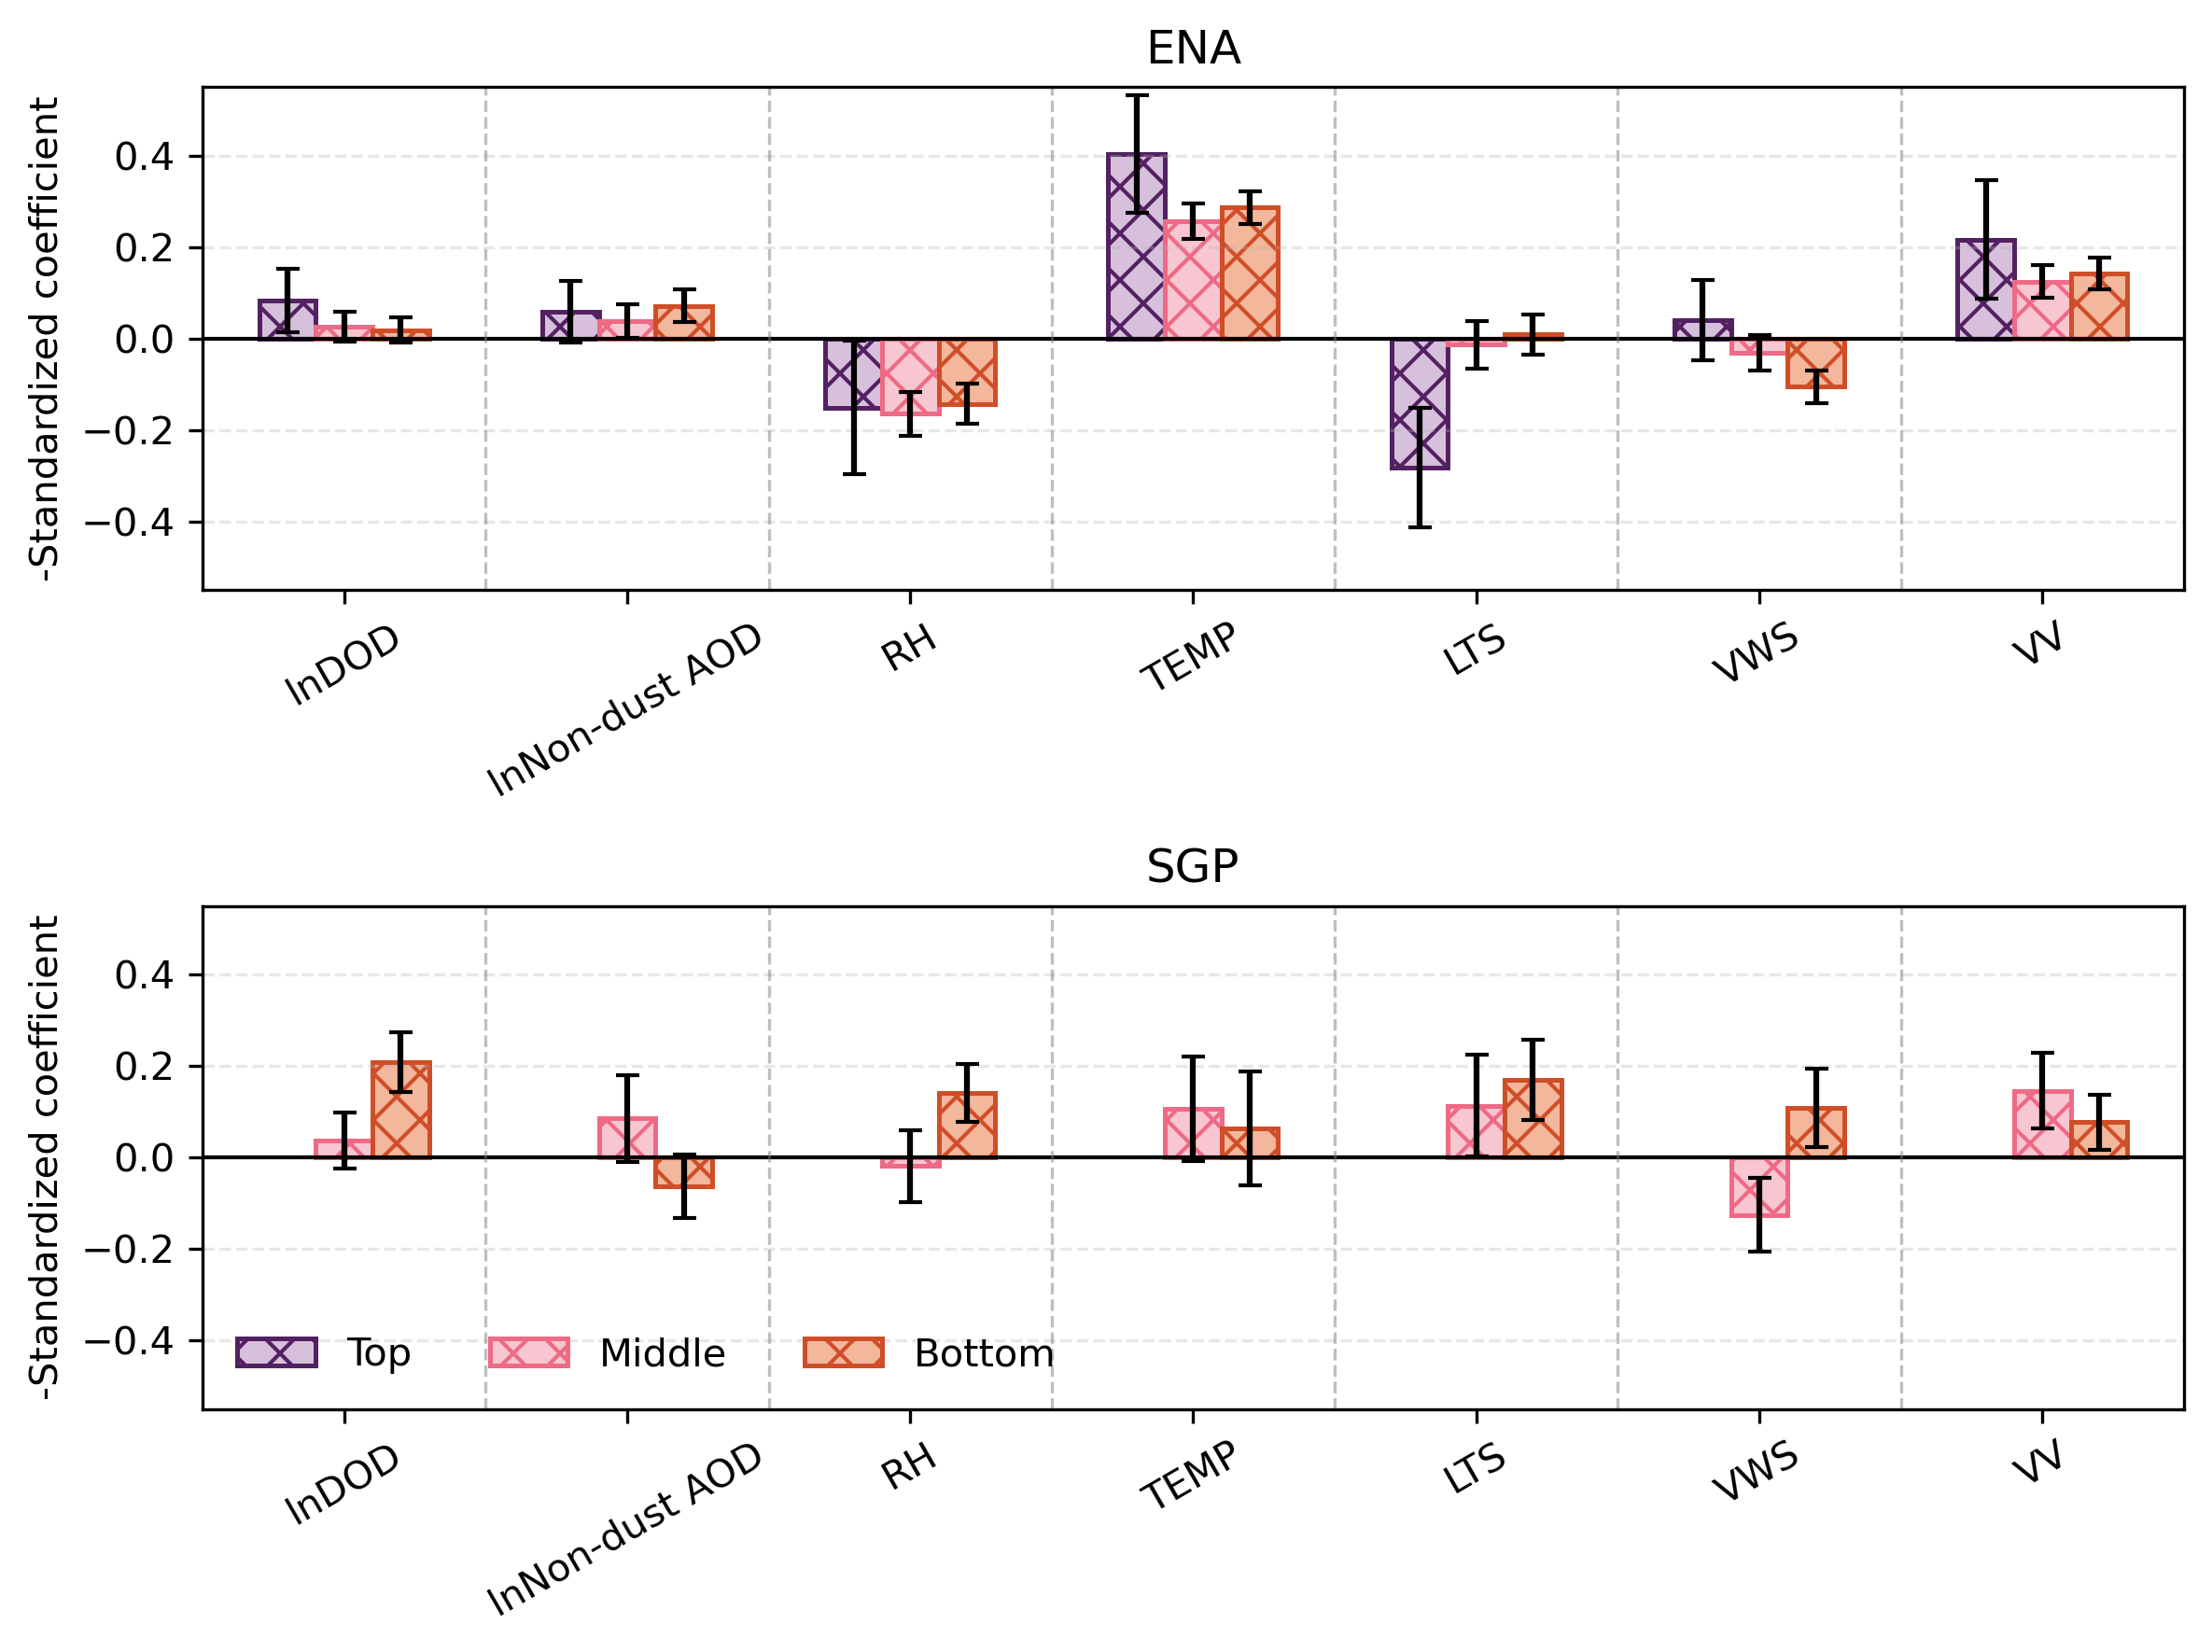


================== ENA ==================

--- top ---
N_2min=174, N_events=150, R2=0.110, Adjusted_R2=0.073
                Beta  Bootstrap_SE  CI95_low  CI95_high  Bootstrap_p
lnDOD         0.0831        0.0693   -0.0467     0.2266       0.2039
lnNonDustAOD  0.0590        0.0673   -0.0674     0.1949       0.3638
RH           -0.1506        0.1465   -0.4198     0.1654       0.3378
TEMP          0.4029        0.1281    0.1487     0.6512       0.0030
LTS          -0.2826        0.1309   -0.5343    -0.0237       0.0340
VWS           0.0403        0.0881   -0.1214     0.2205       0.5977
VV            0.2158        0.1292   -0.0243     0.4803       0.0750

--- middle ---
N_2min=946, N_events=646, R2=0.172, Adjusted_R2=0.166
                Beta  Bootstrap_SE  CI95_low  CI95_high  Bootstrap_p
lnDOD         0.0263        0.0326   -0.0383     0.0891       0.4198
lnNonDustAOD  0.0383        0.0367   -0.0330     0.1090       0.2799
RH           -0.1648        0.0476   -0.2566    -0.0695      

In [5]:
import numpy as np, pandas as pd, statsmodels.api as sm, matplotlib.pyplot as plt

met_vars=["RH","TEMP","LTS","VWS","VV"]; cats=["top","middle","bottom"]
vars_all=["lnDOD","lnNonDustAOD"]+met_vars
cols=["#d6c0db","#f7c6d0","#f3b79c"]; edges=["#532162","#ee6a85","#cf4e28"]
dod_max,min_n,B=0.5,20,2000; rng=np.random.default_rng(42)

def prep_df(df):
    d=df[["event_id","label","Re","main_dod","nondust_AOD"]+met_vars].copy()
    d["label"]=d["label"].astype(str).str.lower()
    for v in ["Re","main_dod","nondust_AOD"]+met_vars: d[v]=pd.to_numeric(d[v],errors="coerce")
    m=np.isfinite(d["Re"])&np.isfinite(d["main_dod"])&np.isfinite(d["nondust_AOD"])&(d["Re"]>0)&(d["main_dod"]>0)&(d["main_dod"]<=dod_max)&(d["nondust_AOD"]>0)
    d=d[m].copy()
    d["lnRe"],d["lnDOD"],d["lnNonDustAOD"]=np.log(d["Re"]),np.log(d["main_dod"]),np.log(d["nondust_AOD"])
    d=d[["event_id","label","lnRe"]+vars_all].replace([np.inf,-np.inf],np.nan).dropna().copy()
    for v in ["lnRe"]+vars_all: d[v]=(d[v]-d[v].mean())/d[v].std(ddof=1)
    return d

def block_fit(d):
    if len(d)<min_n or d["event_id"].nunique()<2: return None
    fit=sm.OLS(d["lnRe"],sm.add_constant(d[vars_all])).fit()
    groups={k:g.index.to_numpy() for k,g in d.groupby("event_id")}; ids=np.array(list(groups)); boot=[]
    for _ in range(B):
        idx=np.concatenate([groups[i] for i in rng.choice(ids,len(ids),replace=True)]); db=d.loc[idx]
        try: boot.append(-sm.OLS(db["lnRe"],sm.add_constant(db[vars_all])).fit().params.reindex(vars_all).values)
        except: pass
    boot=np.asarray(boot); coef=-fit.params.reindex(vars_all).values
    se=boot.std(0,ddof=1); lo,hi=np.percentile(boot,[2.5,97.5],axis=0)
    p=2*np.minimum((np.sum(boot<=0,0)+1)/(len(boot)+1),(np.sum(boot>=0,0)+1)/(len(boot)+1))
    return dict(coef=coef,se=se,lo=lo,hi=hi,p=np.minimum(p,1),N=len(d),N_events=d["event_id"].nunique(),R2=fit.rsquared,Adj_R2=fit.rsquared_adj)

def fit_site(df):
    d=prep_df(df)
    return {c:block_fit(d[d["label"].eq(c)]) for c in cats}

res_ena,res_sgp=fit_site(df_ena_abs),fit_site(df_sgp_abs)

fig,axes=plt.subplots(2,1,figsize=(8,6),dpi=300,sharey=True); x,w=np.arange(len(vars_all)),0.2
for ax,res,site in zip(axes,[res_ena,res_sgp],["ENA","SGP"]):
    for i,c in enumerate(cats):
        r=res[c]; val,err=(r["coef"],r["se"]) if r else (np.full(len(vars_all),np.nan),)*2
        ax.bar(x+(i-1)*w,val,w,yerr=err,capsize=3,color=cols[i],edgecolor=edges[i],lw=1.2,hatch="xx",label=c.capitalize())
    ax.axhline(0,color="k",lw=1)
    for xpos in x[:-1]+0.5: ax.axvline(xpos,ls="--",lw=0.8,color="gray",alpha=0.5)
    ax.set(xlim=(-0.5,len(vars_all)-0.5),ylim=(-0.55,0.55),xticks=x,xticklabels=["lnDOD","lnNon-dust AOD","RH","TEMP","LTS","VWS","VV"],ylabel="-Standardized coefficient",title=site)
    ax.tick_params(axis="x",rotation=30); ax.grid(axis="y",ls="--",alpha=0.3)

axes[1].legend(frameon=False,ncol=3)
plt.tight_layout(); plt.savefig("figsave/METE_nondust_r_e_block.pdf",dpi=300,bbox_inches="tight"); plt.show()

for site,res in zip(["ENA","SGP"],[res_ena,res_sgp]):
    print(f"\n{'='*18} {site} {'='*18}")
    for c in cats:
        r=res[c]; print(f"\n--- {c} ---")
        if r is None: print("Not enough samples"); continue
        print(f"N_2min={r['N']}, N_events={r['N_events']}, R2={r['R2']:.3f}, Adjusted_R2={r['Adj_R2']:.3f}")
        print(pd.DataFrame({"Beta":r["coef"],"Bootstrap_SE":r["se"],"CI95_low":r["lo"],"CI95_high":r["hi"],"Bootstrap_p":r["p"]},index=vars_all).round(4))

Site Configuration  N_events Beta_with_met SE_with_met p_with_met Beta_without_met SE_without_met p_without_met Difference Difference_SE Difference_CI_low Difference_CI_high Difference_p  Difference_significant  N_boot
 ENA           top       150        0.1112      0.0680    0.07396           0.0831         0.0693        0.2039     0.0281        0.0300           -0.0239             0.0932       0.2879                   False    2000
 ENA        middle       646        0.0666      0.0396    0.09595           0.0263         0.0326        0.4198     0.0403        0.0233           -0.0056             0.0855      0.08296                   False    2000
 ENA        bottom      1082       -0.0337      0.0309     0.2799           0.0184         0.0279        0.5087    -0.0521        0.0160           -0.0828            -0.0205     0.001999                    True    2000
 SGP           top         5           NaN         NaN        NaN              NaN            NaN           NaN        NaN  

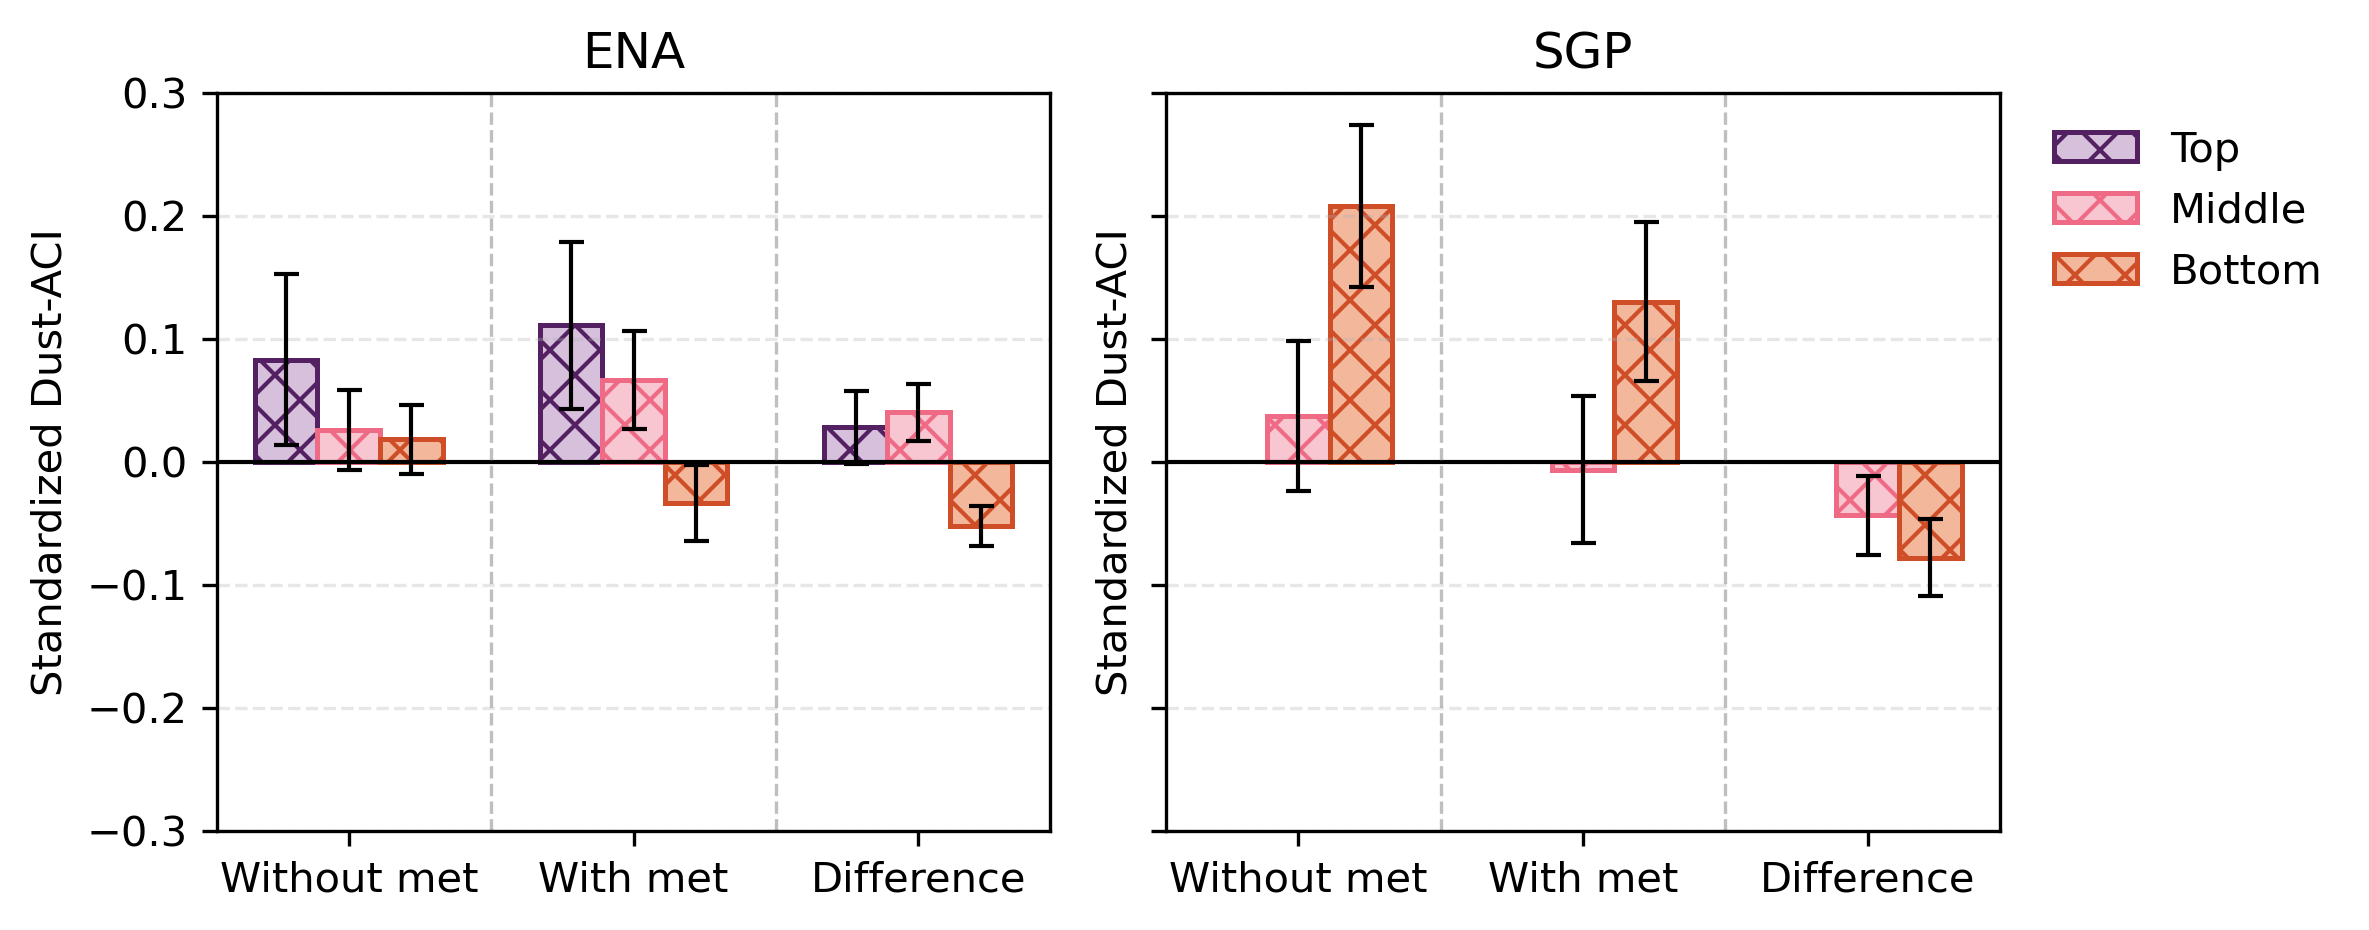

In [5]:
import numpy as np, pandas as pd, statsmodels.api as sm, matplotlib.pyplot as plt

cats,cat_labels=["top","middle","bottom"],["Top","Middle","Bottom"]
met_vars=["RH","TEMP","LTS","VWS","VV"]; adj_vars=["lnDOD","lnNonDustAOD"]+met_vars
cols,edges=["#d6c0db","#f7c6d0","#f3b79c"],["#532162","#ee6a85","#cf4e28"]
dod_max,min_n,n_boot=5e-1,20,2000; rng=np.random.default_rng(42)

def prep_site(df):
    d=df[["event_id","label","Re","main_dod","nondust_AOD"]+met_vars].copy()
    d["label"]=d["label"].astype(str).str.lower()
    for v in ["Re","main_dod","nondust_AOD"]+met_vars: d[v]=pd.to_numeric(d[v],errors="coerce")
    m=d["label"].isin(cats)&np.isfinite(d["Re"])&np.isfinite(d["main_dod"])&np.isfinite(d["nondust_AOD"])&(d["Re"]>0)&(d["main_dod"]>0)&(d["main_dod"]<=dod_max)&(d["nondust_AOD"]>0)
    d=d.loc[m].copy()
    d["lnRe"],d["lnDOD"],d["lnNonDustAOD"]=np.log(d["Re"]),np.log(d["main_dod"]),np.log(d["nondust_AOD"])
    return d[["event_id","label","lnRe","lnDOD","lnNonDustAOD"]+met_vars].replace([np.inf,-np.inf],np.nan).dropna()

def standardize(d):
    d=d.copy()
    for v in ["lnRe","lnDOD","lnNonDustAOD"]+met_vars:
        s=d[v].std(ddof=1); d[v]=(d[v]-d[v].mean())/s if np.isfinite(s) and s>0 else np.nan
    return d

def fit_beta(dc):
    if len(dc)<min_n or dc["event_id"].nunique()<2: return (np.nan,)*6
    f0=sm.OLS(dc["lnRe"],sm.add_constant(dc[["lnDOD"]])).fit()
    f1=sm.OLS(dc["lnRe"],sm.add_constant(dc[adj_vars])).fit()
    return -f0.params["lnDOD"],f0.bse["lnDOD"],f0.pvalues["lnDOD"],-f1.params["lnDOD"],f1.bse["lnDOD"],f1.pvalues["lnDOD"]

def boot_stat(a):
    a=np.asarray(a,float)
    if len(a)<2: return np.nan,np.nan,np.nan,np.nan,len(a)
    se=a.std(ddof=1); lo,hi=np.percentile(a,[2.5,97.5])
    p=2*min((np.sum(a<=0)+1)/(len(a)+1),(np.sum(a>=0)+1)/(len(a)+1))
    return se,lo,hi,min(p,1),len(a)

def bootstrap_block(d):
    boot={}
    for c in cats:
        dc=d[d["label"].eq(c)]
        groups={k:g.index.to_numpy() for k,g in dc.groupby("event_id")}; ids=np.array(list(groups))
        b0s,b1s,diffs=[],[],[]

        if len(dc)>=min_n and len(ids)>=2:
            for _ in range(n_boot):
                idx=np.concatenate([groups[i] for i in rng.choice(ids,len(ids),replace=True)])
                db=d.loc[idx]
                b0,_,_,b1,_,_=fit_beta(db)
                if np.isfinite(b0) and np.isfinite(b1):
                    b0s.append(b0); b1s.append(b1); diffs.append(b0-b1)

        boot[c]=(boot_stat(b0s),boot_stat(b1s),boot_stat(diffs))
    return boot

def calc_site(df,site):
    raw=prep_site(df); d=standardize(raw); boot=bootstrap_block(d); rows=[]
    for c in cats:
        dc=d[d["label"].eq(c)]
        b0,_,_,b1,_,_=fit_beta(dc); diff=b0-b1 if np.isfinite(b0) and np.isfinite(b1) else np.nan
        ne=dc["event_id"].nunique()
        (se0,lo0,hi0,p0,nb0),(se1,lo1,hi1,p1,nb1),(sed,lod,hid,pdiff,nbd)=boot[c]
        rows.append([site,c,ne,b0,se0,p0,b1,se1,p1,diff,sed,lod,hid,pdiff,
                     not(lod<=0<=hid) if np.isfinite(lod) and np.isfinite(hid) else False,nbd])

    return pd.DataFrame(rows,columns=["Site","Configuration","N_events",
        "Beta_with_met","SE_with_met","p_with_met",
        "Beta_without_met","SE_without_met","p_without_met",
        "Difference","Difference_SE","Difference_CI_low","Difference_CI_high",
        "Difference_p","Difference_significant","N_boot"])

df_mean=pd.concat([calc_site(df_ena_abs,"ENA"),calc_site(df_sgp_abs,"SGP")],ignore_index=True)

print(df_mean.to_string(index=False,formatters={
    "Beta_with_met":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "SE_with_met":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "p_with_met":lambda x:f"{x:.4g}" if pd.notna(x) else "NaN",
    "Beta_without_met":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "SE_without_met":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "p_without_met":lambda x:f"{x:.4g}" if pd.notna(x) else "NaN",
    "Difference":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "Difference_SE":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "Difference_CI_low":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "Difference_CI_high":lambda x:f"{x:.4f}" if pd.notna(x) else "NaN",
    "Difference_p":lambda x:f"{x:.4g}" if pd.notna(x) else "NaN"}))

df_mean.to_csv("figsave/dust_aci_with_without_met_nondust_block_bootstrap.csv",index=False)

metrics=[("Beta_without_met","SE_without_met","Without met"),
         ("Beta_with_met","SE_with_met","With met"),
         ("Difference","Difference_SE","Difference")]

x,w=np.arange(3),0.22; errkw=dict(ecolor="k",elinewidth=1,capsize=3,capthick=1)
fig,axes=plt.subplots(1,2,figsize=(8,3.2),dpi=300,sharex=True,sharey=True)

for ax,site in zip(axes,["ENA","SGP"]):
    ds=df_mean[df_mean["Site"].eq(site)]
    for i,c in enumerate(cats):
        r=ds[ds["Configuration"].eq(c)].iloc[0]
        y=[r[m[0]] for m in metrics]; e=[r[m[1]] for m in metrics]
        ax.bar(x+(i-1)*w,y,w,yerr=e,color=cols[i],edgecolor=edges[i],lw=1.2,hatch="xx",error_kw=errkw,label=cat_labels[i])
    ax.axhline(0,color="k",lw=1)
    ax.vlines(x[:-1]+0.5,-0.3,0.3,color="gray",lw=0.8,ls="--",alpha=0.5)
    ax.set(ylim=(-0.3,0.3),xticks=x,xticklabels=[m[2] for m in metrics],ylabel="Standardized Dust-ACI",title=site)
    ax.grid(axis="y",ls="--",alpha=0.3)

axes[1].legend(frameon=False,loc="upper left",bbox_to_anchor=(1.02,1))
plt.tight_layout(); plt.savefig("figsave/dust_aci_with_without_met_difference_e.pdf",dpi=300,bbox_inches="tight"); plt.show()